<a href="https://colab.research.google.com/github/Shahbazhashmi04/amazon-ads-sales-predictor/blob/main/DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Read Me:

We are solving regression problem : in which we predict the value of the target feature eg Sales.



**Libraries Used**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

**Load Data**

In [ ]:
filename = "Amazon_Ads_Data.csv"
data = pd.read_csv(filename)

**Exploratory Data Analysis**

In [ ]:
data.head(5)

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,...,Impressions,Clicks,CTR,Spend(USD),CPC(USD),DPV,Orders,Sales(USD),ACOS,ROAS
0,ORD000001,7/7/2025,Laptop,Electronics,81.88,5.0,401.90,Customer 1,Chicago,Debit Card,...,10,204,0.01,731.547488,45.72,146.31,386,358.09,18.9623,173.0956
1,ORD000002,19/01/2024,Headphones,Sports,164.56,NaN,2751.50,Customer 2,Boston,Debit Card,...,20,470,0.18,400.309626,18.20,80.06,492,408.87,38.8486,229.2747
2,ORD000003,13/12/2023,Tablet,Fashion,146.39,8.0,245.18,Customer 3,Boston,Debit Card,...,30,109,0.19,1494.545155,87.91,498.18,327,379.31,26.2727,144.5537
3,ORD000004,15/01/2024,Camera,Home,109.65,4.0,468.93,Customer 4,Los Angeles,Credit Card,...,40,552,0.06,58.421682,4.49,14.61,188,155.91,8.1646,77.1315
4,ORD000005,11/4/2024,Camera,Electronics,155.88,3.0,2628.00,Customer 5,San Francisco,Credit Card,...,50,664,0.07,376.268631,37.63,125.42,113,114.82,11.4577,52.3531


In [ ]:
data.columns

Index(['Order ID', 'Date', 'Product', 'Category', 'Price', 'Quantity',
       'Total Sales', 'Customer Name', 'Customer Location', 'Payment Method',
       'Status', 'Targeting', 'Campaign bidding strategy', 'Start date',
       'End date', 'Portfolio', 'Budget(USD)', 'Top-of-search IS', 'Cost type',
       'Impressions', 'Clicks', 'CTR', 'Spend(USD)', 'CPC(USD)', 'DPV',
       'Orders', 'Sales(USD)', 'ACOS', 'ROAS'],
      dtype='object')

In [ ]:
data.tail(5)

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,...,Impressions,Clicks,CTR,Spend(USD),CPC(USD),DPV,Orders,Sales(USD),ACOS,ROAS
7795,ORD007796,29/08/2024,Headphones,Fashion,237.17,3.0,1813.98,Customer 7796,NaN,Debit Card,...,77960,903,0.19,282.788422,11.78,141.39,280,419.42,38.0153,136.5365
7796,ORD007797,13/05/2024,Laptop,Sports,184.95,6.0,354.90,Customer 7797,New York,Debit Card,...,77970,2,0.07,280.902661,11.70,70.23,86,69.31,4.5541,30.0540
7797,ORD007798,17/12/2023,Camera,Electronics,NaN,10.0,2991.03,Customer 7798,New York,Credit Card,...,77980,59,0.08,651.015579,31.00,162.75,275,389.34,20.9364,168.9077
7798,ORD007799,27/05/2025,Tablet,Fashion,423.89,9.0,2175.57,Customer 7799,Boston,Debit Card,...,77990,84,0.02,1235.583766,44.13,247.12,75,70.37,3.5317,17.7772
7799,ORD007800,20/08/2023,Tablet,Electronics,279.96,10.0,2966.85,Customer 7800,Boston,PayPal,...,78000,750,0.15,430.910186,30.78,107.73,305,323.52,16.9346,82.3785


In [ ]:
data.shape

(7800, 29)

In [ ]:
data.describe()

,Price,Quantity,Total Sales,Budget(USD),Top-of-search IS,Impressions,Clicks,CTR,Spend(USD),CPC(USD),DPV,Orders,Sales(USD),ACOS,ROAS
count,7410.000000,7410.000000,7408.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000
mean,255.287061,5.536977,1407.907495,2570.051410,7.506510,39005.000000,498.791282,0.105451,1023.560993,56.778165,328.305935,252.959103,278.484556,19.410146,108.998342
std,137.977494,2.901226,1130.087576,1413.207611,1.441188,22518.103828,289.208361,0.057809,560.172401,38.274224,222.865978,144.145182,171.992537,12.887895,76.628527
min,20.100000,1.000000,20.460000,100.000000,5.000000,10.000000,1.000000,0.010000,50.304583,1.750000,10.060000,1.000000,0.720000,0.044800,0.271900
25%,137.760000,3.000000,473.130000,1341.000000,6.270000,19507.500000,249.000000,0.060000,538.318419,26.710000,152.100000,129.000000,134.335000,9.006350,49.014900
50%,255.640000,6.000000,1110.320000,2580.000000,7.510000,39005.000000,492.000000,0.110000,1020.215465,51.420000,292.390000,255.000000,267.990000,17.739200,96.665900
75%,373.465000,8.000000,2038.000000,3799.000000,8.750000,58502.500000,752.250000,0.160000,1502.447334,77.630000,449.172500,379.000000,403.477500,27.904875,153.222750
max,499.810000,10.000000,4990.500000,4998.000000,10.000000,78000.000000,1000.000000,0.200000,1999.716223,199.730000,999.850000,500.000000,737.830000,71.105700,440.866300


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7800 entries, 0 to 7799
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Order ID                   7800 non-null   object 
 1   Date                       7800 non-null   object 
 2   Product                    7800 non-null   object 
 3   Category                   7800 non-null   object 
 4   Price                      7410 non-null   float64
 5   Quantity                   7410 non-null   float64
 6   Total Sales                7408 non-null   float64
 7   Customer Name              7800 non-null   object 
 8   Customer Location          7644 non-null   object 
 9   Payment Method             7800 non-null   object 
 10  Status                     7800 non-null   object 
 11  Targeting                  7800 non-null   object 
 12  Campaign bidding strategy  7800 non-null   object 
 13  Start date                 7800 non-null   objec

In [ ]:
data.isnull().sum()

,0
Order ID,0
Date,0
Product,0
Category,0
Price,390
Quantity,390
Total Sales,392
Customer Name,0
Customer Location,156
Payment Method,0


In [ ]:
data.duplicated().sum()

np.int64(0)

**Remove Unneccesary Columns**

In [ ]:
columns_to_drop = [
    'Order ID', 'Customer Name', 'Customer Location', 'Payment Method','Category','Product',
    'Status', 'Portfolio', 'Start date', 'End date', 'Top-of-search IS','Total Sales','DPV'
]
data.drop(columns=columns_to_drop, axis=1, inplace=True)

**Inserting Nan on empty or 0 value**

In [ ]:
data.replace('', pd.NA, inplace=True)
numeric_cols = data.select_dtypes(include='number').columns
data[numeric_cols] = data[numeric_cols].replace(0, np.nan)

In [ ]:
data.columns

Index(['Date', 'Price', 'Quantity', 'Targeting', 'Campaign bidding strategy',
       'Budget(USD)', 'Cost type', 'Impressions', 'Clicks', 'CTR',
       'Spend(USD)', 'CPC(USD)', 'Orders', 'Sales(USD)', 'ACOS', 'ROAS'],
      dtype='object')

**Feature engineering**

In [ ]:
# data['Date'] = pd.to_datetime(data['Date'], errors='coerce', dayfirst=True)

# # Extract features
# data['Day_of_Week'] = data['Date'].dt.dayofweek
# data['Month'] = data['Date'].dt.month
# data['Is_Weekend'] = data['Day_of_Week'].apply(lambda x: 1 if x in [5,6] else (0 if x in [0,1,2,3,4] else np.nan))

# # Fill NaN and convert to int
# data['Day_of_Week'] = data['Day_of_Week'].fillna(-1).astype(int)
# data['Month'] = data['Month'].fillna(-1).astype(int)

# # Map to names safely
# day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# month_names = ['January', 'February', 'March', 'April', 'May', 'June',
#                'July', 'August', 'September', 'October', 'November', 'December']

# data['Day_of_Week_Name'] = data['Day_of_Week'].apply(lambda x: day_names[x] if 0 <= x <= 6 else 'Unknown')
# data['Month_Name'] = data['Month'].apply(lambda x: month_names[x - 1] if 1 <= x <= 12 else 'Unknown')

data.drop('Date', axis=1, inplace=True)


2. Out of all the people who clicked your ad, how many actually made a purchase?
3. How much are you spending for each impression (how often your ad appears)?

In [ ]:

data['Click_Conversion_Rate'] = data['Orders'] / data['Clicks']
data['Spend_per_Impression'] = data['Spend(USD)'] / data['Impressions']

In [ ]:
data.columns

Index(['Price', 'Quantity', 'Targeting', 'Campaign bidding strategy',
       'Budget(USD)', 'Cost type', 'Impressions', 'Clicks', 'CTR',
       'Spend(USD)', 'CPC(USD)', 'Orders', 'Sales(USD)', 'ACOS', 'ROAS',
       'Click_Conversion_Rate', 'Spend_per_Impression'],
      dtype='object')

**Before Winsorizing the Data Plots**

Outliers capped, dataset size remains unchanged: (7800, 17)


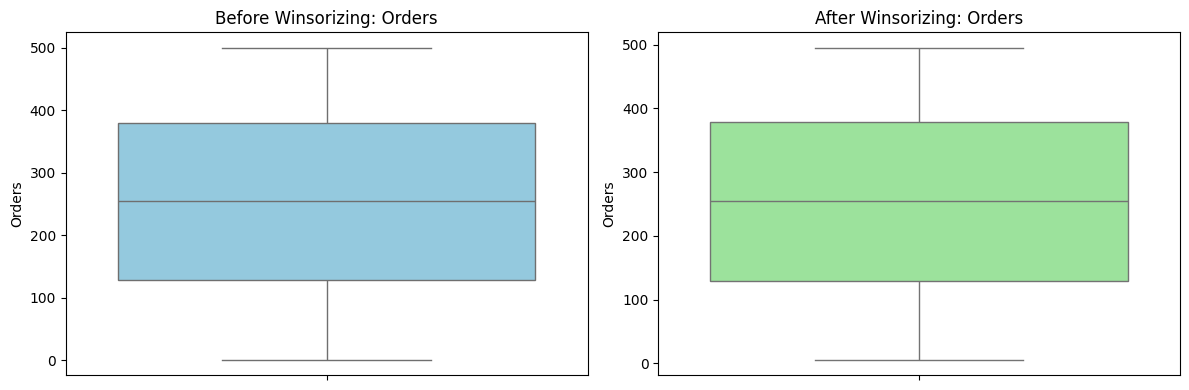

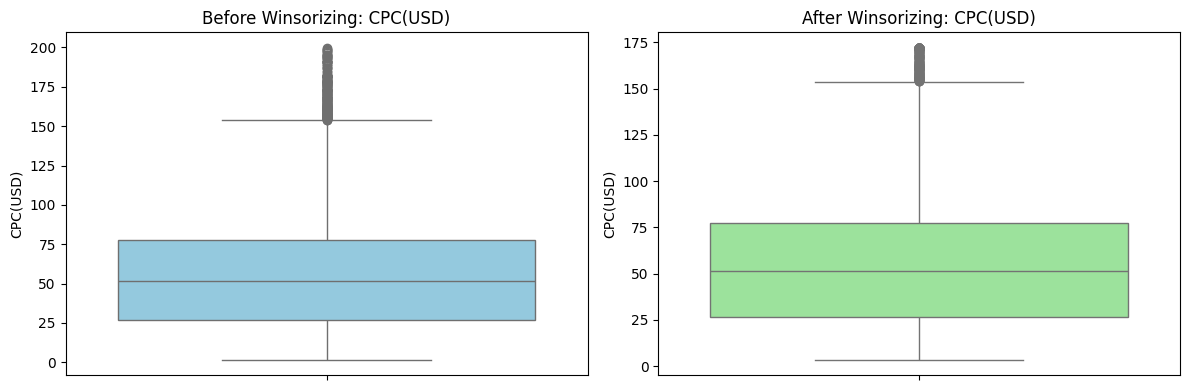

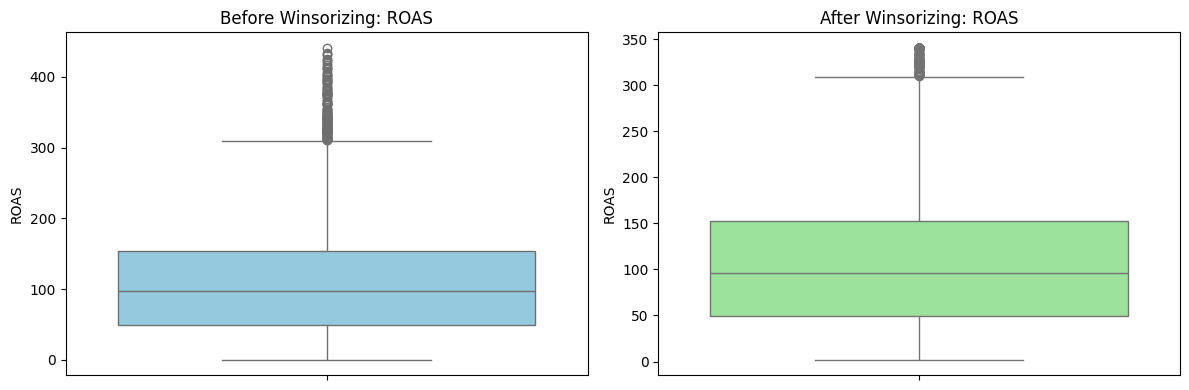

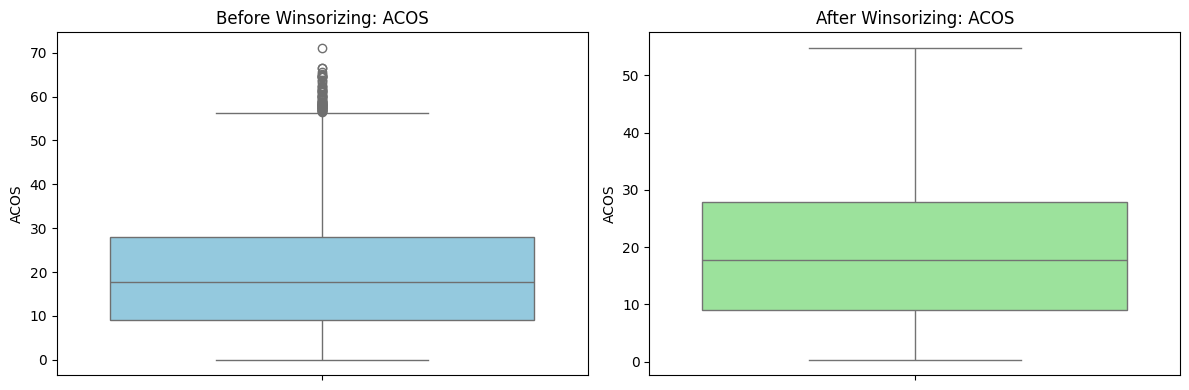

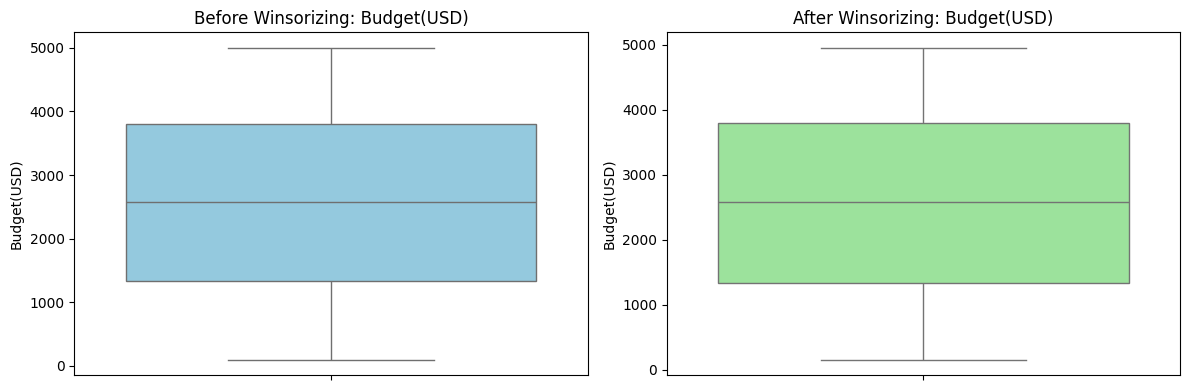

In [ ]:
from scipy.stats.mstats import winsorize

originalData = data.copy()

def winsorize_df(df, cols, limits=(0.01, 0.01)):
    df_copy = df.copy()
    for col in cols:
        if df_copy[col].dtype != 'object':
            df_copy[col] = winsorize(df_copy[col], limits=limits)
    return df_copy

numerical_cols = data.select_dtypes(include='number').columns
data = winsorize_df(data, numerical_cols, limits=(0.01, 0.01))

print("Outliers capped, dataset size remains unchanged:", data.shape)


numerical_cols = data.select_dtypes(include='number').columns

cols_to_plot = ['Orders', 'CPC(USD)', 'ROAS','ACOS','Budget(USD)']

for col in cols_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(y=originalData[col], ax=axes[0], color='skyblue')
    axes[0].set_title(f"Before Winsorizing: {col}")

    sns.boxplot(y=data[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f"After Winsorizing: {col}")

    plt.tight_layout()
    plt.show()


**Shapiro-Wilk test Check the distribution**

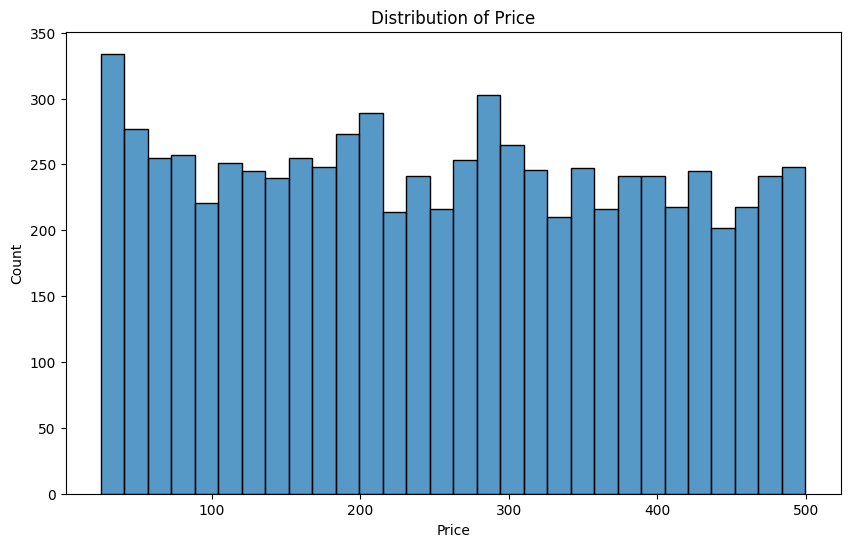

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7410.
  res = hypotest_fun_out(*samples, **kwds)


Normality test for Price: Statistics=0.9563762624180477, p-value=2.1998821410110467e-42
The data for Price does NOT follow a normal distribution (reject H0).


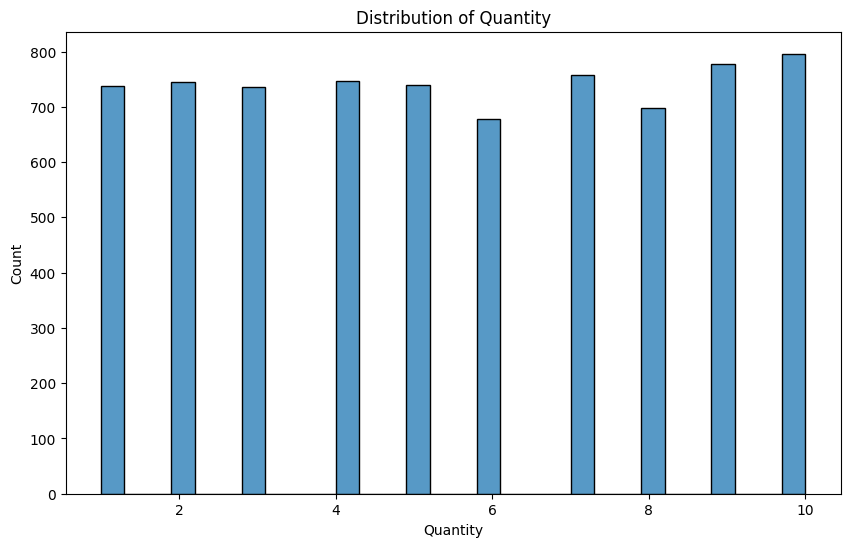

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7410.
  res = hypotest_fun_out(*samples, **kwds)


Normality test for Quantity: Statistics=0.9325380266320361, p-value=1.5261191465613152e-49
The data for Quantity does NOT follow a normal distribution (reject H0).


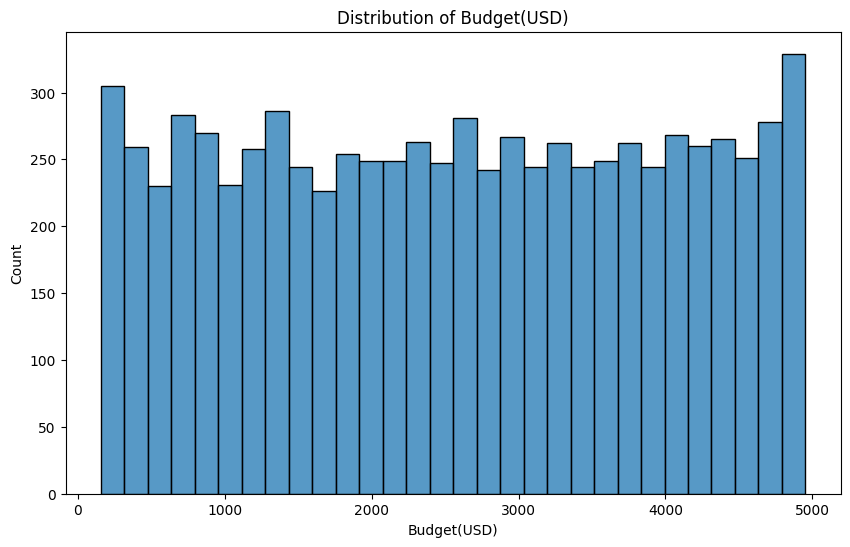

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7800.
  res = hypotest_fun_out(*samples, **kwds)


Normality test for Budget(USD): Statistics=0.9533946542754664, p-value=2.825304834284152e-44
The data for Budget(USD) does NOT follow a normal distribution (reject H0).


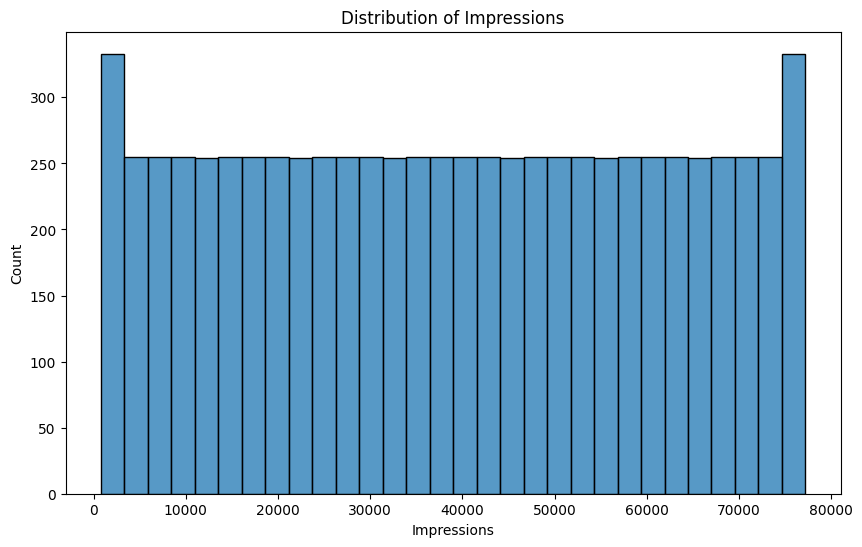

Normality test for Impressions: Statistics=0.954123884652343, p-value=5.072839647521452e-44
The data for Impressions does NOT follow a normal distribution (reject H0).


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7800.
  res = hypotest_fun_out(*samples, **kwds)


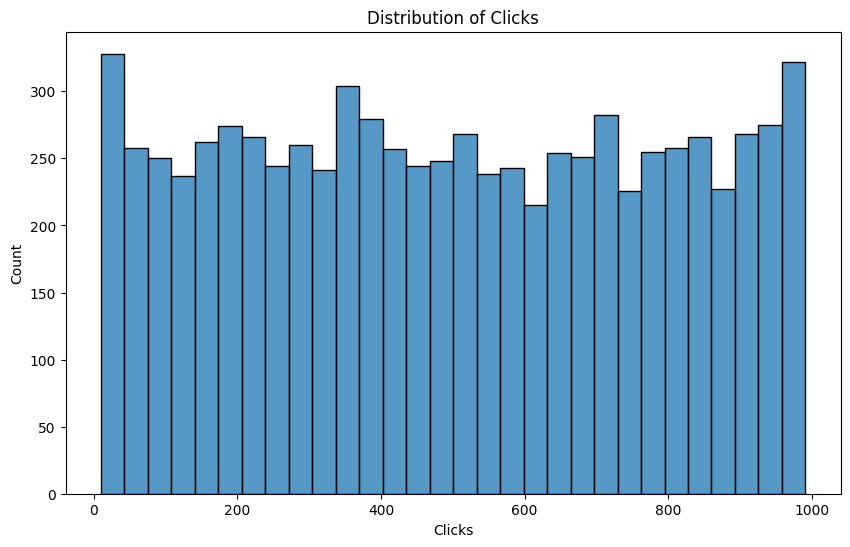

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7800.
  res = hypotest_fun_out(*samples, **kwds)


Normality test for Clicks: Statistics=0.9537073691813958, p-value=3.628021573130194e-44
The data for Clicks does NOT follow a normal distribution (reject H0).


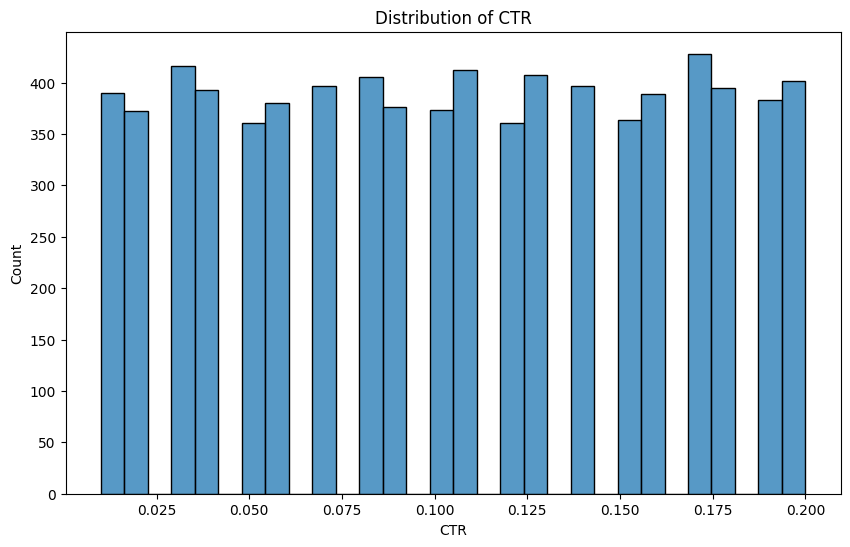

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7800.
  res = hypotest_fun_out(*samples, **kwds)


Normality test for CTR: Statistics=0.9485915404145314, p-value=7.12960445674275e-46
The data for CTR does NOT follow a normal distribution (reject H0).


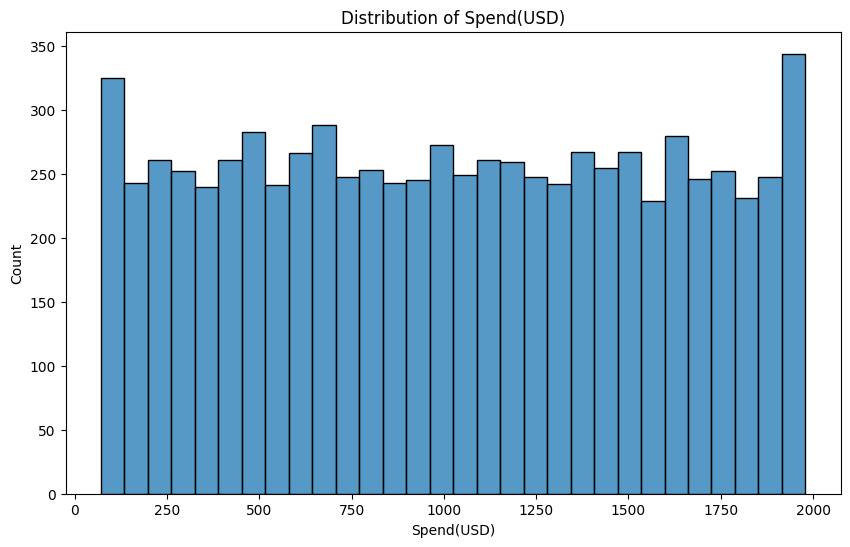

Normality test for Spend(USD): Statistics=0.9550054822508292, p-value=1.0398134315949155e-43
The data for Spend(USD) does NOT follow a normal distribution (reject H0).


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7800.
  res = hypotest_fun_out(*samples, **kwds)


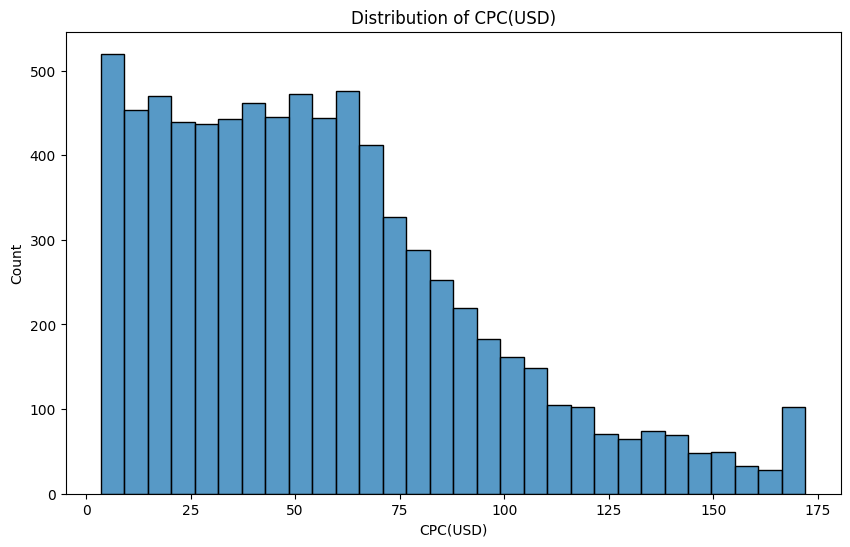

Normality test for CPC(USD): Statistics=0.9396562971740984, p-value=1.5101938125902556e-48
The data for CPC(USD) does NOT follow a normal distribution (reject H0).


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7800.
  res = hypotest_fun_out(*samples, **kwds)


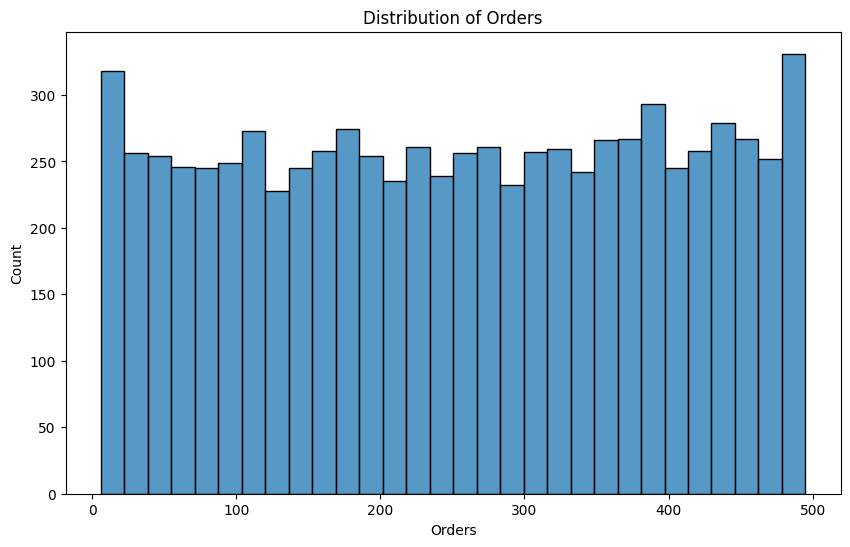

Normality test for Orders: Statistics=0.953419627943865, p-value=2.88215159099844e-44
The data for Orders does NOT follow a normal distribution (reject H0).


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7800.
  res = hypotest_fun_out(*samples, **kwds)


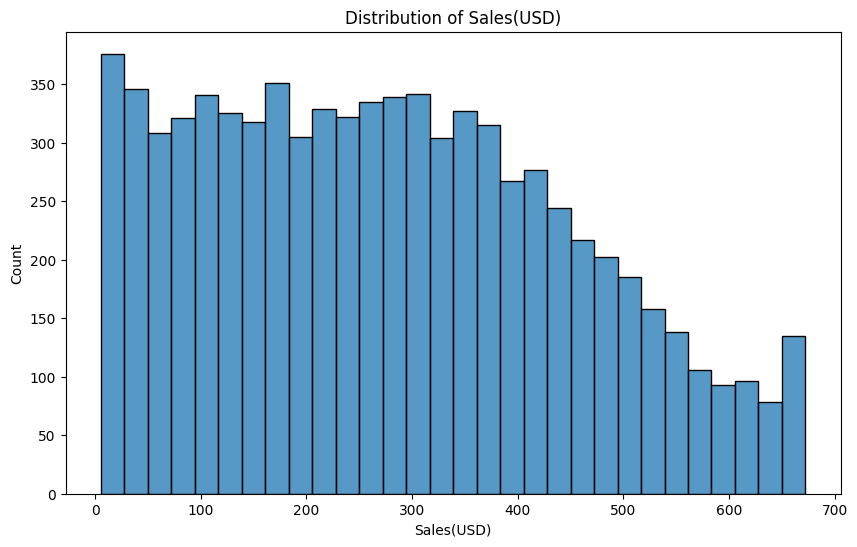

Normality test for Sales(USD): Statistics=0.9682509150160671, p-value=2.6431335448746774e-38
The data for Sales(USD) does NOT follow a normal distribution (reject H0).


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7800.
  res = hypotest_fun_out(*samples, **kwds)


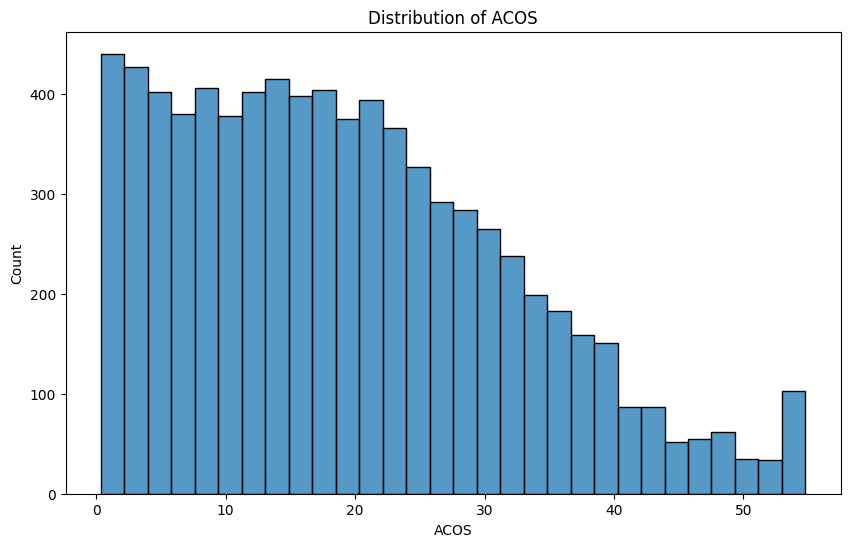

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7800.
  res = hypotest_fun_out(*samples, **kwds)


Normality test for ACOS: Statistics=0.9595352456028593, p-value=5.025179549990008e-42
The data for ACOS does NOT follow a normal distribution (reject H0).


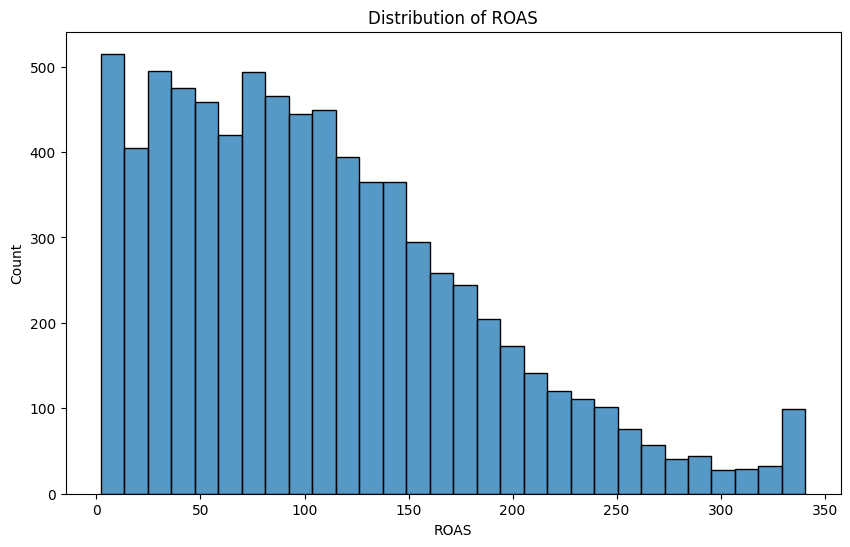

Normality test for ROAS: Statistics=0.9432934912148426, p-value=1.6814807530618774e-47
The data for ROAS does NOT follow a normal distribution (reject H0).


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7800.
  res = hypotest_fun_out(*samples, **kwds)


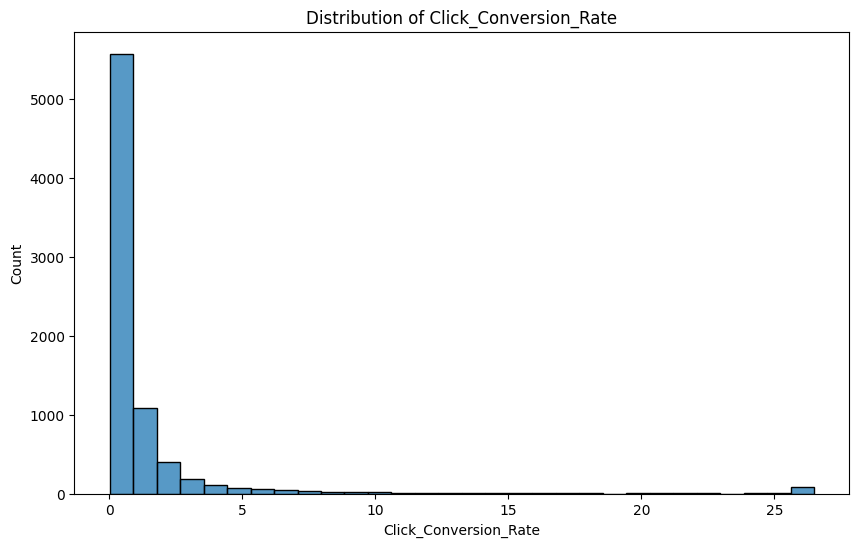

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7800.
  res = hypotest_fun_out(*samples, **kwds)


Normality test for Click_Conversion_Rate: Statistics=0.351634197872007, p-value=2.2640085160083485e-97
The data for Click_Conversion_Rate does NOT follow a normal distribution (reject H0).


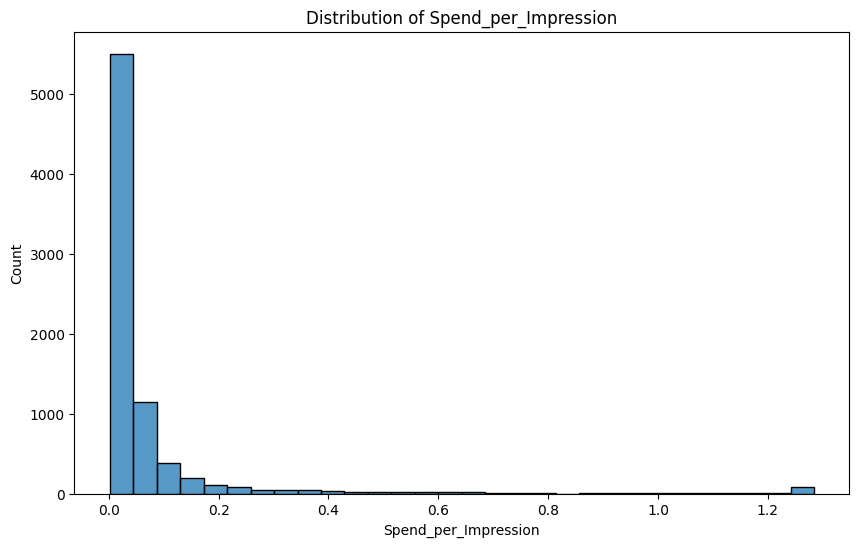

Normality test for Spend_per_Impression: Statistics=0.3641535360900853, p-value=6.700235249951537e-97
The data for Spend_per_Impression does NOT follow a normal distribution (reject H0).


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7800.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
#Use Shapiro-Wilk Test to check if data is normally distributed
numerical_columns = data.select_dtypes(include='number').columns

for column in numerical_columns:
    # Visualize the distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data[column], kde=False, bins=30)
    plt.title(f'Distribution of {column}')
    plt.show()

    stat, p_value = stats.shapiro(data[column].dropna())  # dropna to handle any remaining NaN values
    print(f'Normality test for {column}: Statistics={stat}, p-value={p_value}')
    if p_value > 0.05:
        print(f"The data for {column} follows a normal distribution (fail to reject H0).")
    else:
        print(f"The data for {column} does NOT follow a normal distribution (reject H0).")

**Handle Null Values**

**For catgorial Columns**
We fill the missing values with most repeated value in the col

In [ ]:
data.shape

(7800, 17)

In [ ]:
#We apply Mode Imputation technique to fill the data of categorical features
categorical_columns = data.select_dtypes(exclude='number').columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
data[categorical_columns] = categorical_imputer.fit_transform(data[categorical_columns])

Use median imputation to handle skewness and avoid introducing bias due to extreme values.


In [ ]:
numerical_columns = data.select_dtypes(include='number').columns

# Step 3: Replace inf/-inf and extremely large values with NaN
data[numerical_columns] = data[numerical_columns].replace([np.inf, -np.inf], np.nan)

data[numerical_columns] = data[numerical_columns].apply(
    lambda col: col.map(lambda x: np.nan if isinstance(x, (int, float)) and abs(x) > 1e10 else x)
)

# Step 4: Impute missing values using median for all skewed numeric columns
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
data[numerical_columns] = imputer.fit_transform(data[numerical_columns])

**Separate Training Test Model**

In [ ]:
X = data.drop(['Sales(USD)'], axis=1)
y = data['Sales(USD)']

#We split in 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Converting All Numeric Fields to 0 in bet 1
Converting All String values into numeric

In [ ]:
categorical_features = categorical_columns

target_column = 'Sales(USD)'

numerical_features = data.select_dtypes(include='number').columns.tolist()
numerical_features.remove(target_column)

#one-hot coding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('scaler', StandardScaler())
        ]), numerical_features),
        ('cat', Pipeline([
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ])

To build a complete machine learning workflow that chains:

1. Preprocessing
2. Model training

Ensures that whenever you fit or predict, preprocessing happens automatically inside the pipeline.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

# Define pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        random_state=42
    ))
])

# Train the model
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)


# Evaluate
print("🔸 Random Forest Results")
print("R² Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))


🔸 Random Forest Results
R² Score: 0.9462166259281537
MAE: 27.111364358974363


In [ ]:
#Fast & Better than random forest
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

extra_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(random_state=42))
])

extra_model.fit(X_train, y_train)
y_pred_extra = extra_model.predict(X_test)

print("🔸 Extra Trees Results")
print("R² Score:", r2_score(y_test, y_pred_extra))
print("MAE:", mean_absolute_error(y_test, y_pred_extra))


🔸 Extra Trees Results
R² Score: 0.9458017205511507
MAE: 26.96395807692308


In [ ]:
#Boosting technique:Multiple models work and learn from each other’s mistakes.
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting pipeline
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

print("\n🔸 Gradient Boosting Results")
print("R² Score:", r2_score(y_test, gb_pred))
print("MAE:", mean_absolute_error(y_test, gb_pred))



🔸 Gradient Boosting Results
R² Score: 0.943973191014713
MAE: 28.584235107843494


**Important Features**

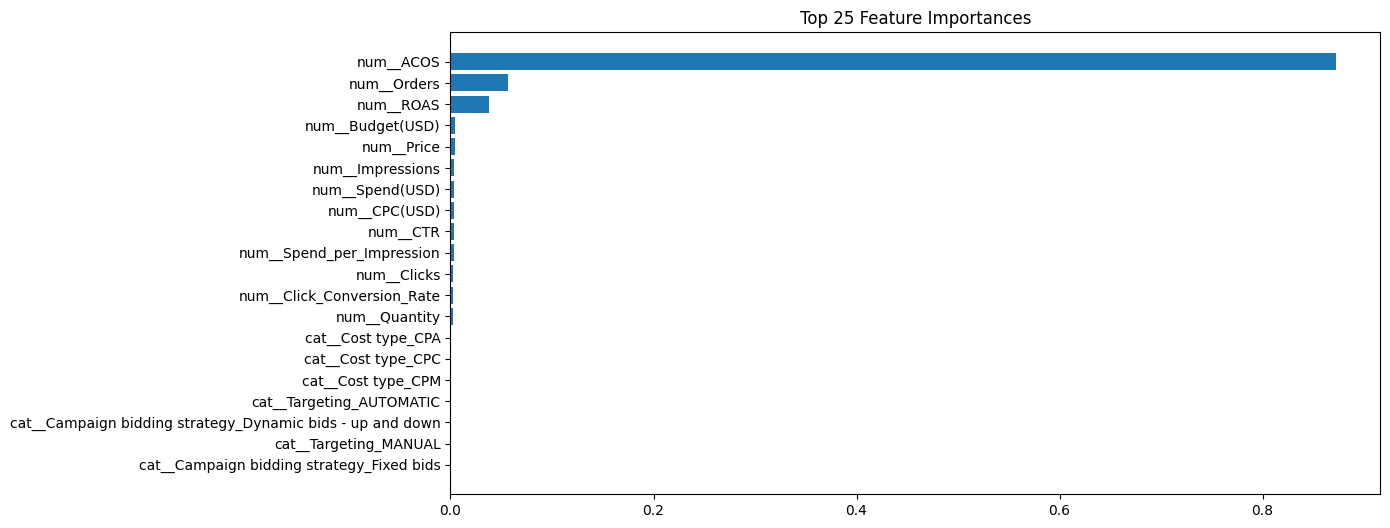

In [ ]:
#Choosing 25 best features that improve model prediction
import pandas as pd
import matplotlib.pyplot as plt

# After fitting your model
rf_pipeline.named_steps['regressor'].feature_importances_  # only works if you've fit the model

# Get feature names after transformation
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Create a DataFrame of feature importances
importances = rf_pipeline.named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df.sort_values(by='importance', ascending=False, inplace=True)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['feature'][:25], feature_importance_df['importance'][:25])
plt.gca().invert_yaxis()
plt.title("Top 25 Feature Importances")
plt.show()


**Using Stacking**

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression


# Base regressors
base_models = [
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42)),
    ('et', ExtraTreesRegressor(n_estimators=200, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=200, random_state=42))
]

# Final estimator (meta-model)
final_estimator = LinearRegression()

# Stacking Regressor pipeline
stack_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('stack', StackingRegressor(
        estimators=base_models,
        final_estimator=final_estimator,
        cv=5,
        n_jobs=-1
    ))
])

# Fit
stack_pipeline.fit(X_train, y_train)

# Predict
y_pred = stack_pipeline.predict(X_test)

# Evaluate
from sklearn.metrics import r2_score, mean_absolute_error
print("🔹 Stacked R² Score:", r2_score(y_test, y_pred))
print("🔹 Stacked MAE:", mean_absolute_error(y_test, y_pred))


🔹 Stacked R² Score: 0.947075678271725
🔹 Stacked MAE: 26.82306017186784


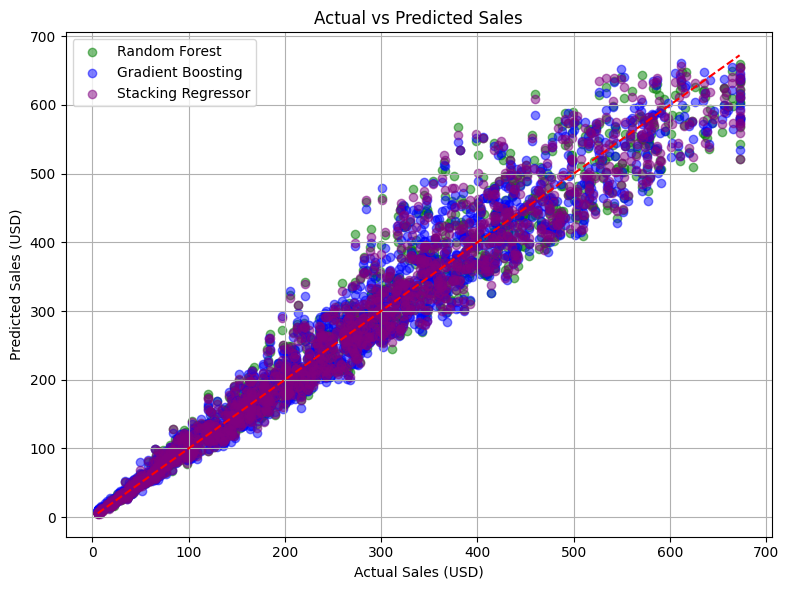

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='Random Forest', color='green')
plt.scatter(y_test, gb_pred, alpha=0.5, label='Gradient Boosting', color='blue')
plt.scatter(y_test, y_pred, alpha=0.5, label='Stacking Regressor', color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Sales (USD)')
plt.ylabel('Predicted Sales (USD)')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Server Work

Server Lib

In [ ]:
!pip install pyngrok --quiet


In [ ]:
X_train.columns

Index(['Price', 'Quantity', 'Targeting', 'Campaign bidding strategy',
       'Budget(USD)', 'Cost type', 'Impressions', 'Clicks', 'CTR',
       'Spend(USD)', 'CPC(USD)', 'Orders', 'ACOS', 'ROAS',
       'Click_Conversion_Rate', 'Spend_per_Impression'],
      dtype='object')

In [ ]:
pip install flask-cors


In [ ]:
# Install required packages
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok, conf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

conf.get_default().auth_token = "2yYULiLeA7Fg3AHnbuzp9VQeRQe_6WwHyqCuxi2PgKXiGvrWL"

metrics = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "R2": r2_score(y_test, y_pred),
    "MAPE": mean_absolute_percentage_error(y_test, y_pred)
}

# Flask App
app = Flask(__name__)
CORS(app)
public_url = ngrok.connect(5000)
print(" * ngrok tunnel URL:", public_url)

@app.route("/")
def home():
    return "API is running"

@app.route("/columns", methods=["GET"])
def summary():
    return jsonify(data.columns)

@app.route("/metrics", methods=["GET"])
def get_metrics():
    return jsonify(metrics)

@app.route("/predict", methods=["POST"])
def predict():
    input_data = request.json
    input_df = pd.DataFrame([input_data])
    print("Input DataFrame columns:", input_df.columns)

    input_df["Click_Conversion_Rate"] = input_df["Orders"] / input_df["Clicks"]
    input_df["Spend_per_Impression"] = input_df["Spend(USD)"] / input_df["Impressions"]

    prediction = stack_pipeline.predict(input_df)[0]
    return jsonify({"predicted_value": prediction})


# Start Flask
app.run(port=5000, host="0.0.0.0")



 * ngrok tunnel URL: NgrokTunnel: "https://fd68-34-134-6-95.ngrok-free.app" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [17/Jun/2025 05:08:41] "OPTIONS /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Jun/2025 05:08:41] "POST /predict HTTP/1.1" 200 -


Input DataFrame columns: Index(['Spend(USD)', 'Impressions', 'Orders', 'Clicks', 'CPC(USD)',
       'Budget(USD)', 'Cost type', 'Campaign bidding strategy', 'Quantity',
       'Price', 'CTR', 'Targeting', 'ROAS', 'ACOS'],
      dtype='object')


INFO:werkzeug:127.0.0.1 - - [17/Jun/2025 05:11:10] "OPTIONS /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [17/Jun/2025 05:11:11] "POST /predict HTTP/1.1" 200 -


Input DataFrame columns: Index(['Spend(USD)', 'Impressions', 'Orders', 'Clicks', 'CPC(USD)',
       'Budget(USD)', 'Cost type', 'Campaign bidding strategy', 'Quantity',
       'Price', 'CTR', 'Targeting', 'ROAS', 'ACOS'],
      dtype='object')
